# Deep MLP for Just-In-Time Defect Prediction

Trains a fully-connected deep neural network on the 13 structured
commit-level metrics produced by the preprocessing pipeline. This is
the baseline architecture in the four-model comparison (MLP, Wide &
Deep, TabNet, TabTransformer): it makes no assumptions about feature
structure, learning only weighted combinations of the input features
through stacked dense layers.

## 1. Environment Setup

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt

## 2. Configuration

In [3]:
DATA_DIR = "/content/drive/MyDrive/DL-Assignment/data/processed"
RESULTS_DIR = "/content/drive/MyDrive/DL-Assignment/results/mlp"

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HIDDEN_DIMS = [128, 64, 32]
DROPOUT = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10

os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed: int) -> None:
    """Fix random seeds across all libraries for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Load Preprocessed Artifacts

All four models consume the identical artifacts produced by the
preprocessing notebook, ensuring a controlled comparison.

In [4]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
class_weights = np.load(os.path.join(DATA_DIR, "class_weights.npy"))

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"Class weights [clean, buggy]: {class_weights}")

INPUT_DIM = X_train.shape[1]

X_train: (52133, 12)  X_val: (24430, 12)  X_test: (30111, 12)
Class weights [clean, buggy]: [0.7051289  1.71874588]


## 4. Dataset and DataLoader Construction

In [5]:
def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    """Wrap numpy arrays into a PyTorch DataLoader."""
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [6]:
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

## 5. Model Architecture

A feedforward network with three hidden layers (128, 64, 32 units),
ReLU activations, batch normalization, and dropout for
regularization. The output layer produces two logits (clean, buggy).

In [7]:
class DeepMLP(nn.Module):
    """Fully-connected deep neural network for binary commit classification."""

    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [8]:
model = DeepMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)
Total parameters: 12,514
Trainable parameters: 12,514


## 6. Loss Function and Optimizer

Cross-entropy loss is weighted by the class weights computed during
preprocessing, penalizing misclassification of the minority (buggy)
class more heavily than the majority (clean) class.

In [9]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

## 7. Training Loop with Early Stopping

Training halts if validation loss does not improve for
`EARLY_STOPPING_PATIENCE` consecutive epochs. The model weights from
the best-performing epoch on the validation set are restored before
final evaluation.

In [10]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> float:
    """Run a single training or evaluation epoch. Pass optimizer=None for eval."""
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [11]:
best_val_loss = float("inf")
epochs_without_improvement = 0
best_state_dict = None

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, None, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

model.load_state_dict(best_state_dict)
print(f"Restored best model with val_loss={best_val_loss:.4f}")

Epoch   1 | train_loss=0.6173 | val_loss=0.5843
Epoch   2 | train_loss=0.5952 | val_loss=0.5752
Epoch   3 | train_loss=0.5873 | val_loss=0.5688
Epoch   4 | train_loss=0.5832 | val_loss=0.5631
Epoch   5 | train_loss=0.5804 | val_loss=0.5652
Epoch   6 | train_loss=0.5767 | val_loss=0.5623
Epoch   7 | train_loss=0.5756 | val_loss=0.5631
Epoch   8 | train_loss=0.5737 | val_loss=0.5613
Epoch   9 | train_loss=0.5729 | val_loss=0.5605
Epoch  10 | train_loss=0.5706 | val_loss=0.5611
Epoch  11 | train_loss=0.5708 | val_loss=0.5573
Epoch  12 | train_loss=0.5687 | val_loss=0.5591
Epoch  13 | train_loss=0.5693 | val_loss=0.5571
Epoch  14 | train_loss=0.5679 | val_loss=0.5544
Epoch  15 | train_loss=0.5659 | val_loss=0.5606
Epoch  16 | train_loss=0.5659 | val_loss=0.5625
Epoch  17 | train_loss=0.5643 | val_loss=0.5596
Epoch  18 | train_loss=0.5638 | val_loss=0.5693
Epoch  19 | train_loss=0.5629 | val_loss=0.5545
Epoch  20 | train_loss=0.5609 | val_loss=0.5643
Epoch  21 | train_loss=0.5583 | val_loss

## 8. Training Curves

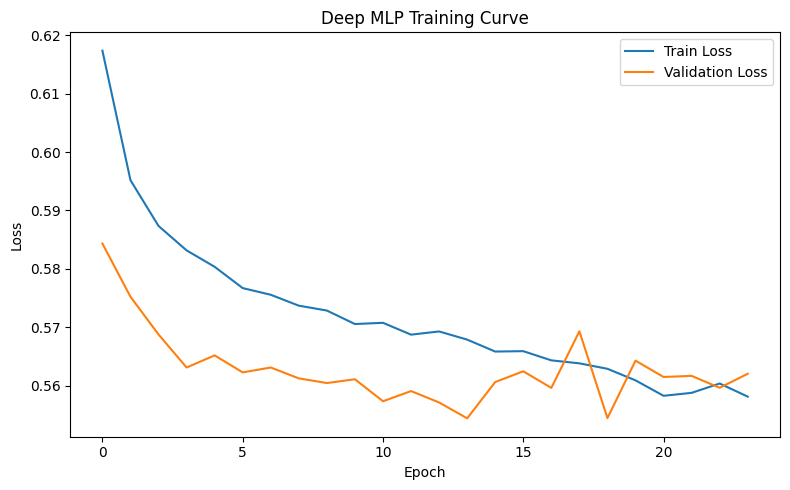

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curve.png"))
plt.show()

## 9. Evaluation

Final evaluation is performed once on the held-out test set
(2017-2019 commits), which was not used for training or
hyperparameter tuning.

In [13]:
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> dict:
    """Compute predictions and probabilities for an entire dataloader."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_labels.extend(y_batch.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [14]:
results = evaluate(model, test_loader, DEVICE)

metrics = {
    "accuracy": accuracy_score(results["labels"], results["preds"]),
    "precision": precision_score(results["labels"], results["preds"]),
    "recall": recall_score(results["labels"], results["preds"]),
    "f1": f1_score(results["labels"], results["preds"]),
    "roc_auc": roc_auc_score(results["labels"], results["probs"]),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

accuracy  : 0.6791
precision : 0.3482
recall    : 0.7578
f1        : 0.4772
roc_auc   : 0.7758


In [15]:
print(classification_report(
    results["labels"], results["preds"], target_names=["Clean", "Buggy"]
))

              precision    recall  f1-score   support

       Clean       0.92      0.66      0.77     24293
       Buggy       0.35      0.76      0.48      5818

    accuracy                           0.68     30111
   macro avg       0.63      0.71      0.62     30111
weighted avg       0.81      0.68      0.71     30111



## 10. Confusion Matrix

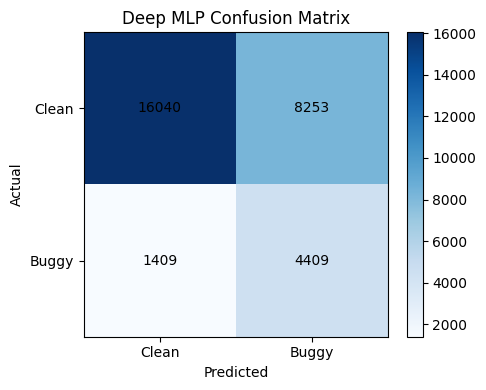

In [16]:
cm = confusion_matrix(results["labels"], results["preds"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Clean", "Buggy"])
ax.set_yticklabels(["Clean", "Buggy"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Deep MLP Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
plt.show()

## 11. Persist Model and Results

The trained weights, evaluation metrics, and training history are
saved for later comparison against the other three architectures.

In [17]:
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "mlp_weights.pt"))

with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(RESULTS_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

print(f"Model, metrics, and history saved to {RESULTS_DIR}")

Model, metrics, and history saved to /content/drive/MyDrive/DL-Assignment/results/mlp


## Summary

| Artifact | Description |
|---|---|
| `mlp_weights.pt` | Trained model state dict (best validation epoch) |
| `metrics.json` | Test-set accuracy, precision, recall, F1, ROC-AUC |
| `history.json` | Per-epoch train/validation loss |
| `training_curve.png` | Loss curve plot |
| `confusion_matrix.png` | Test-set confusion matrix |